In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
PROJECT_DIR = Path(r"E:\Credit Risk Assessment System")   # <- single consistent folder now
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
DATA_DIR = PROJECT_DIR / "dataset" / "processed_models"
SHAP_DIR = RESULTS_DIR / "shap"

c:\Users\sharm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Map includes Tuned XGBoost (GPU) — Notebook 11 may now recommend it by name
MODEL_FILE_MAP = {
    "Logistic Regression": ("logistic_regression_model.pkl", "scaled"),
    "Decision Tree": ("decision_tree_model.pkl", "unscaled"),
    "Random Forest": ("random_forest_model.pkl", "unscaled"),
    "XGBoost": ("xgboost_model.pkl", "unscaled"),
    "Tuned XGBoost (GPU)": ("best_xgboost_model.pkl", "unscaled"),
}

final_summary = pd.read_csv(RESULTS_DIR / "final_model_summary.csv")
final_model_name = final_summary["recommended_model"].iloc[0]

model_filename, data_type = MODEL_FILE_MAP[final_model_name]
model = joblib.load(MODELS_DIR / model_filename)

print("Final Model:", final_model_name)
print("Model Type:", type(model).__name__)

if type(model).__name__ == "XGBClassifier":
    device = model.get_xgb_params().get("device")
    print("XGBoost device:", device)
    if device != "cuda":
        print("WARNING: expected device='cuda' for the GPU-tuned model.")

Final Model: Tuned XGBoost (GPU)
Model Type: XGBClassifier
XGBoost device: cuda


In [3]:
X_test = pd.read_csv(DATA_DIR / f"X_test_{data_type}.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()
print("Test shape:", X_test.shape)

Test shape: (61503, 149)


In [4]:
n_samples = min(5000, len(X_test))
X_shap = X_test.sample(n=n_samples, random_state=RANDOM_STATE)
print(f"SHAP sample size: {len(X_shap)} of {len(X_test)}")

SHAP sample size: 5000 of 61503


In [8]:
background = shap.sample(X_shap, 100, random_state=42)
explainer = shap.Explainer(model.predict_proba, background)
explainer_type = "Generic Explainer (predict_proba-based, fallback)"
shap_values_obj = explainer(X_shap)
shap_values = shap_values_obj.values[:, :, 1]  # class 1

PermutationExplainer explainer: 5001it [18:14,  4.57it/s]                          


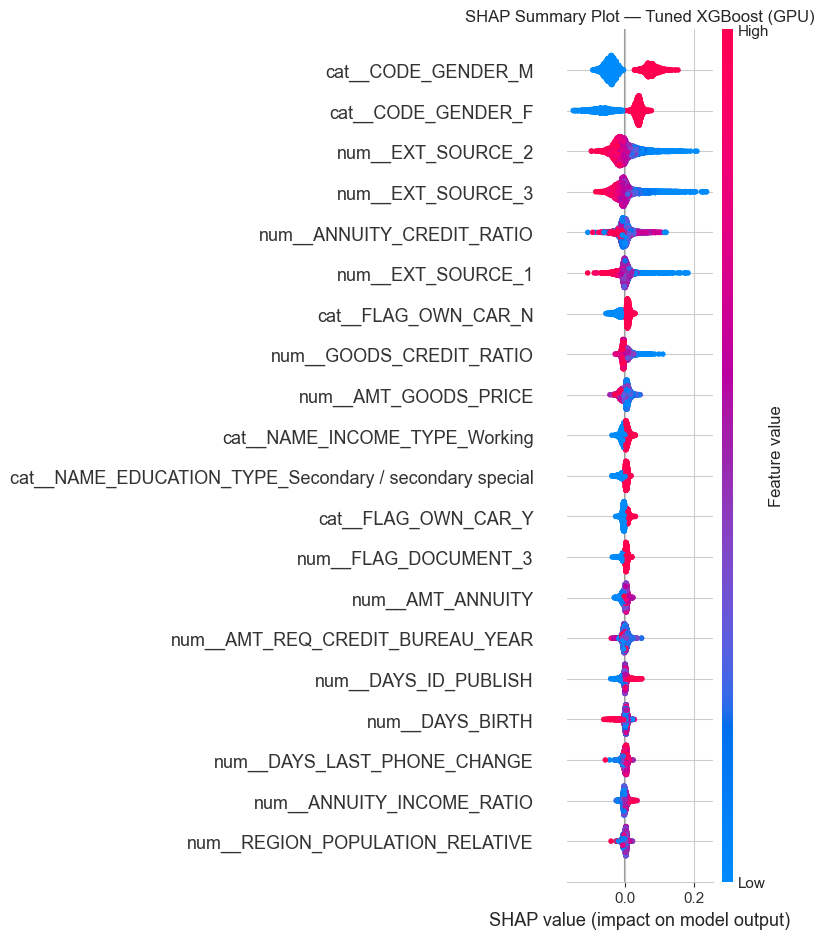

,Feature,Mean Absolute SHAP
20,cat__CODE_GENDER_M,0.054097
19,cat__CODE_GENDER_F,0.048382
109,num__EXT_SOURCE_2,0.025042
108,num__EXT_SOURCE_3,0.025033
119,num__ANNUITY_CREDIT_RATIO,0.013079
107,num__EXT_SOURCE_1,0.012182
98,cat__FLAG_OWN_CAR_N,0.012095
110,num__GOODS_CREDIT_RATIO,0.008768
122,num__AMT_GOODS_PRICE,0.008686
12,cat__NAME_INCOME_TYPE_Working,0.006886


In [9]:
mean_abs_shap = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean Absolute SHAP": np.abs(shap_values).mean(axis=0),
}).sort_values("Mean Absolute SHAP", ascending=False)
top20 = mean_abs_shap.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.title(f"SHAP Summary Plot — {final_model_name}")
plt.tight_layout()
plt.show()
display(top20)

In [10]:
SHAP_DIR.mkdir(parents=True, exist_ok=True)
mean_abs_shap.to_csv(SHAP_DIR / "shap_feature_importance.csv", index=False)
top20.to_csv(SHAP_DIR / "top20_shap_features.csv", index=False)
print("Saved SHAP results to", SHAP_DIR)

Saved SHAP results to E:\Credit Risk Assessment System\results\shap
